# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: XX     |  |
| :-------------|:-------------|
| Student naam Roel van der Ouderaa| Student Studienummer 6424139 |
| Student naam Bart de Jong| Student Studienummer 6531598 |
| Student naam Lucas Everstein| Student Studienummer 3 |

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld |11:30 |
| Mijlpaal 2: opstelling ontworpen |14:00 |
| Mijlpaal 3: Eerste kalibratie meting gedaan|14:30|
| Mijlpaal 4: inleveren |16:30|
| Pauze 1| 12:45 - 13:45|
| Pauze 2| 15:30-15:45 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](Schets.jpg "analyse: ideeen")
![Alt](Schets_Bart.jpg "analyse: ideeen")
![Alt](Scehtsen_Lucas.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | weegschaal| moet een onzekerheid hebben van minimaal 1 gram.  |
|krachtsensor | weegschaal | Moet een bereik hebben tussen de 0 en 2 kg |
|krachtsensor | weegschaal|  Moet ijkbaar zijn tussen 0 en 2kg. |
|Temperatuursensor| automatisch instelling thermostaat | temperatuursensor moet tegen temepraturen van -10 en 40 graden celcius kunnen zonder kapot te gaan|
|Temperatuursensor | toepassing omschrijving | Nauwkeurigheid van 1 gram|
|Temperatuursensor | toepassing omschrijving | De sensor moet de lokale temperatuur meten(temperatuur op de plek van de sensor).|
|magneetsensor |kompas| Onderscheid maken tussen noord en zuid, waarbij zuid de hoogste en noord de laagste waarde in arduino bits is.|
|magneetsensor | kompas| Moet een bereik kunnen meten tussen -65muT en  65muT|
|magneetsensor | kompas | De bepaling van Noord mag niet meer dan 10 graden afwijken|

Groep 15 heeft gekozen voor magneetsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Er is een telefoon te zien, die de graden meet. Hiermee kan de magneetsensor gekalibeerd worden; door te meten welke graden hoort bij een waarde in Arduino. Daarnaast is de arduino te zien de waardes procest en doorgeeft. Op het bord is een schakeling gemaakt met een weerstand en de magneetsensor, waarmee de sterkte van het magneetveld gemeten kan worden. 

 ![Alt](Schets_meetopstelling.jpeg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 

De rotatie van de magneetsensor. 

2. Over welk bereik ga je deze variabelen veranderen?

Tussen 0 en 360 graden. 

3. Wat ga je allemaal meten?

We meten de rotatie magneetsensor en veldsterkte. 

4. Hoeveel metingen ga je doen?

24 metingen. 

5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?

Ja, want aan de hand een telefoon kan worden gecontroleerd of er onderscheid in noord en zuid kan worden gemaakt. Ditzelfde geldt voor de voor de afwijking van 10 graden.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Er is een telefoon te zien, die de graden meet. Hiermee kan de magneetsensor gekalibeerd worden; door te meten welke graden hoort bij een waarde in Arduino. Daarnaast is de arduino te zien de waardes procest en doorgeeft. Op het bord is een schakeling gemaakt met een weerstand en de magneetsensor, waarmee de sterkte van het magneetveld gemeten kan worden. 
 ![Alt](Meetopstelling.jpeg "meetopstelling student")

Meetplan: We hebben eerst vier metingen gedaan, voor de hoofdrichting; op basis hiervan hebben we de orientatie gekalibreed. Daarna is er met een stapgrootte van 15 graden gemeten. 
 ![Alt](Kalibratie.jpg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
import numpy as np
Hoeken = np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255,])+60
arduino_bits_1 = np.array([11.5, 11.5, 10, 9, 8.5, 7.5, 8.0, 9.0, 10.0, 10.0, 12.0, 13.0, 13.5, 12.5, 12.0, 11.0, 11.5, 11.0 ])


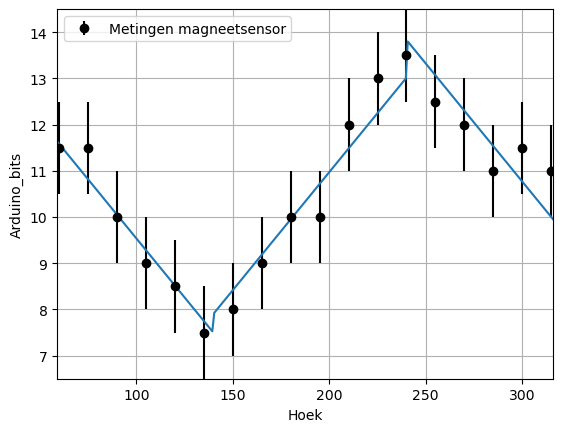

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
def function(Hoeken,a, b, c, d):
    return np.where(Hoeken <140,
                    -a * Hoeken + b,
                    np.where(Hoeken < 240,
                             a * Hoeken + c, 
                             -a * Hoeken + d)


    )
values, cov = curve_fit(function, Hoeken, arduino_bits_1)
a = values[0]
b = values[1]
c = values[2]
d = values[3]
#e = values[4]
random_hoeken = np.linspace(360, 0, 360)

plt.errorbar(Hoeken, arduino_bits_1, yerr= 1, fmt='ko', label='Metingen magneetsensor')
plt.plot(random_hoeken, function(random_hoeken, a, b,c, d))
plt.xlabel('Hoek')
plt.ylabel('Arduino_bits')
plt.xlim(min(Hoeken)-1, max(Hoeken)+1)
plt.ylim(min(arduino_bits_1)-1, max(arduino_bits_1)+1)
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline


De gebruikte sensor is een hall effect sensor, dit betekend dat de sensor op een lage waarde geeft des te dichter bij die een noordelijke pool van een magneetveld is en een hogere waarde des te dichterbij die bij een zuidpool is. Op basis van deze kennis is de grafiek op te delen in drie grafieken. Zo zal er een verband naar en van de noord- en zuidpool met dezelfde richtingcoëficient. Dit zal in principe zichzelf herhalen over meerdere volledige rotaties.

## *Opdracht 7*: Iteratie nodig?

We gaan niet itereren. We hebben genoeg datapunten voor het maken van een fit en meer datapunten zal niet de conclusie veranderen. 

## *Opdracht 8*: Conclusie, leerdoel

De sensor is niet bruikbaar voor het maken van een kompas in een omgeving met veel magnetische velden. Een van de criteria is dat de kompas op 10 graden nauwkeurig kan meten, echter zijn de waardes niet consistent bij meerdere metingen van dezelfde hoek; waardoor het niet voldoet.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.


### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.



 ![Alt](Schets_meetopstelling.jpeg "schets student")
Er is een telefoon te zien, die de graden meet. Hiermee kan de magneetsensor gekalibeerd worden; door te meten welke graden hoort bij een waarde in Arduino. Daarnaast is de arduino te zien de waardes procest en doorgeeft. Op het bord is een schakeling gemaakt met een weerstand en de magneetsensor, waarmee de sterkte van het magneetveld gemeten kan worden. 
 ![Alt](Meetopstelling.jpeg "meetopstelling student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Krachtsensor | weegschaal| moet een onzekerheid hebben van minimaal 1 gram.  |
|krachtsensor | weegschaal | Moet een bereik hebben tussen de 0 en 2 kg |
|krachtsensor | weegschaal|  Moet ijkbaar zijn tussen 0 en 2kg. |
|Temperatuursensor| automatisch instelling thermostaat | temperatuursensor moet tegen temepraturen van -10 en 40 graden celcius kunnen zonder kapot te gaan|
|Temperatuursensor | toepassing omschrijving | Nauwkeurigheid van 1 gram|
|Temperatuursensor | toepassing omschrijving | De sensor moet de lokale temperatuur meten(temperatuur op de plek van de sensor)|
|magneetsensor |kompas| Onderscheid maken tussen noord en zuid, waarbij zuid de hoogste en noord de laagste waarde in arduino bits is.|
|magneetsensor | kompas| Moet een bereik kunnen meten tussen -65muT en  65muT|
|magneetsensor | kompas | De bepaling van Noord mag niet meer dan 10 graden afwijken|

Groep 15 heeft gekozen voor magneetsensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Er is een telefoon te zien, die de graden meet. Hiermee kan de magneetsensor gekalibeerd worden; door te meten welke graden hoort bij een waarde in Arduino. Daarnaast is de arduino te zien de waardes procest en doorgeeft. Op het bord is een schakeling gemaakt met een weerstand en de magneetsensor, waarmee de sterkte van het magneetveld gemeten kan worden. 
 ![Alt](Meetopstelling.jpeg "meetopstelling student")

In [3]:
import numpy as np
Hoeken = np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255,])+60
arduino_bits_1 = np.array([11.5 , 11.5, 10, 9, 8.5, 7.5, 8.0, 9.0, 10.0, 10.0, 12.0, 13.0, 13.5, 12.5, 12.0, 11.0, 11.5, 11.0 ])

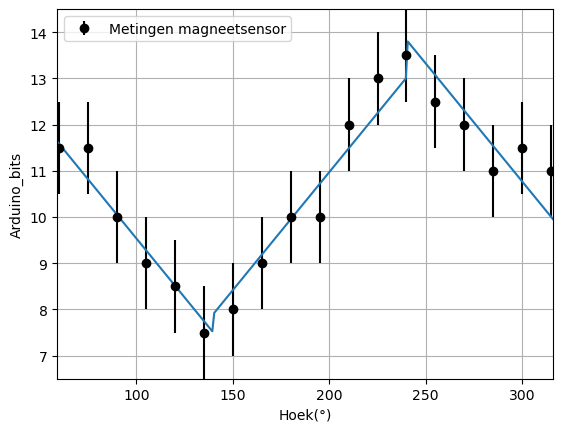

In [4]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
def function(Hoeken,a, b, c, d):
    return np.where(Hoeken <140,
                    -a * Hoeken + b,
                    np.where(Hoeken < 240,
                             a * Hoeken + c, 
                             -a * Hoeken + d)


    )
values, cov = curve_fit(function, Hoeken, arduino_bits_1)
a = values[0]
b = values[1]
c = values[2]
d = values[3]
#e = values[4]
random_hoeken = np.linspace(360, 0, 360)

plt.errorbar(Hoeken, arduino_bits_1, yerr= 1, fmt='ko', label='Metingen magneetsensor')
plt.plot(random_hoeken, function(random_hoeken, a, b,c, d))
plt.xlabel('Hoek(°)')
plt.ylabel('Arduino_bits')
plt.xlim(min(Hoeken)-1, max(Hoeken)+1)
plt.ylim(min(arduino_bits_1)-1, max(arduino_bits_1)+1)
plt.legend(loc='upper left')
plt.grid()
plt.show()

# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum hello.
%matplotlib inline

## *Opdracht 8*: Conclusie, leerdoel

De sensor is niet bruikbaar voor het maken van een kompas in een omgeving met veel magnetische velden. Een van de criteria is dat de kompas op 10 graden nauwkeurig kan meten, echter zijn de waardes niet consistent bij meerdere metingen van dezelfde hoek; waardoor het niet voldoet.